In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/jalesummak/spotify-track-ranking-project/spotify_ranked.pkl
/kaggle/input/notebooks/jalesummak/spotify-track-ranking-project/__results__.html
/kaggle/input/notebooks/jalesummak/spotify-track-ranking-project/__notebook__.ipynb
/kaggle/input/notebooks/jalesummak/spotify-track-ranking-project/__output__.json
/kaggle/input/notebooks/jalesummak/spotify-track-ranking-project/custom.css
/kaggle/input/notebooks/jalesummak/spotify-track-ranking-project/__results___files/__results___19_0.png
/kaggle/input/notebooks/jalesummak/spotify-track-ranking-project/__results___files/__results___37_0.png
/kaggle/input/notebooks/jalesummak/spotify-track-ranking-project/__results___files/__results___28_0.png
/kaggle/input/datasets/maharshipandya/-spotify-tracks-dataset/dataset.csv


In [2]:
import numpy as np             
import pandas as pd             
import matplotlib.pyplot as plt
import seaborn as sns           
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder


sns.set_style('whitegrid')  

print('NumPy version:', np.__version__)   
print('Pandas version:', pd.__version__)

NumPy version: 2.0.2
Pandas version: 2.3.3


In [3]:
df = pd.read_csv('/kaggle/input/datasets/maharshipandya/-spotify-tracks-dataset/dataset.csv')
df.shape

(114000, 21)

In [4]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [6]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [7]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

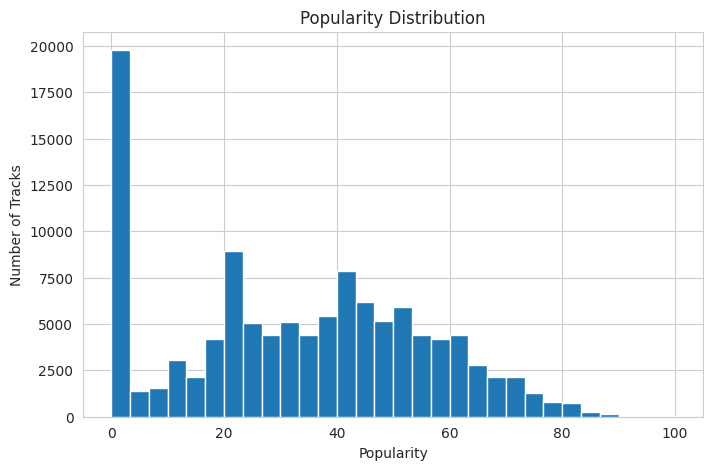

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

plt.hist(df['popularity'], bins=30)

plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.ylabel('Number of Tracks')

plt.show()

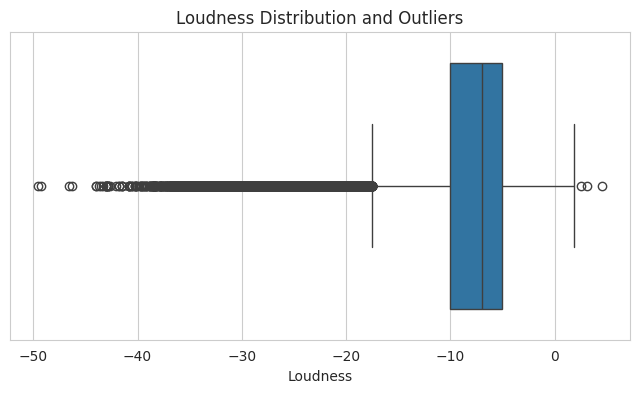

In [9]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['loudness'])

plt.title('Loudness Distribution and Outliers')
plt.xlabel('Loudness')

plt.show()

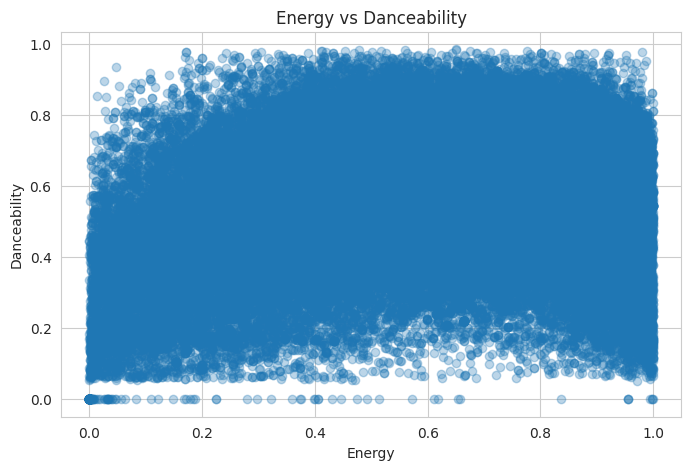

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['energy'],
    df['danceability'],
    alpha=0.3
)

plt.title('Energy vs Danceability')
plt.xlabel('Energy')
plt.ylabel('Danceability')

plt.show()

In [11]:
numeric_cols = [
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'tempo',
    'valence'
]

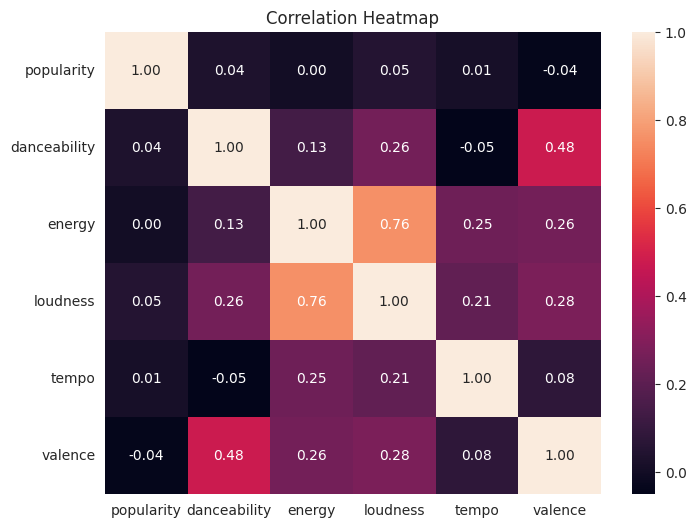

In [12]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [13]:
df.isnull().sum().sort_values(ascending=False)


artists             1
track_name          1
album_name          1
Unnamed: 0          0
track_id            0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [14]:
df = df.dropna(
    subset=['artists', 'album_name', 'track_name']
)
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [15]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
le = LabelEncoder()

df['explicit_encoded'] = le.fit_transform(df['explicit'])

In [18]:
df[['explicit', 'explicit_encoded']].drop_duplicates()

,explicit,explicit_encoded
0,False,0
59,True,1


In [19]:
top_genres = df['track_genre'].value_counts().head(5).index

sample = df[
    df['track_genre'].isin(top_genres)
]

In [20]:
one_hot = pd.get_dummies(
    sample['track_genre'],
    prefix='genre'
)

one_hot.head()

,genre_acoustic,genre_afrobeat,genre_alt-rock,genre_alternative,genre_ambient
0,True,False,False,False,False
1,True,False,False,False,False
2,True,False,False,False,False
3,True,False,False,False,False
4,True,False,False,False,False


In [21]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [22]:
scale_cols = [
    'tempo',
    'loudness'
]
standard_scaler = StandardScaler()

standard_scaled = standard_scaler.fit_transform(
    df[scale_cols]
)

In [23]:
minmax_scaler = MinMaxScaler()

normalized_scaled = minmax_scaler.fit_transform(
    df[scale_cols]
)

In [24]:
comparison = pd.DataFrame({
    'tempo_raw': df['tempo'].values[:5],
    'tempo_standardized': standard_scaled[:5, 0],
    'tempo_normalized': normalized_scaled[:5, 0],

    'loudness_raw': df['loudness'].values[:5],
    'loudness_standardized': standard_scaled[:5, 1],
    'loudness_normalized': normalized_scaled[:5, 1]
})

comparison

,tempo_raw,tempo_standardized,tempo_normalized,loudness_raw,loudness_standardized,loudness_normalized
0,87.917,-1.141854,0.361245,-6.746,0.300825,0.791392
1,77.489,-1.489708,0.318397,-17.235,-1.784739,0.597377
2,76.332,-1.528303,0.313643,-9.734,-0.293289,0.736123
3,181.740,1.987857,0.746758,-18.515,-2.039246,0.573701
4,119.949,-0.073343,0.492863,-9.681,-0.282751,0.737103


In [25]:
feature_cols = [
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'tempo',
    'valence',
    'explicit_encoded'
]
X = df[feature_cols].dropna()

In [26]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [27]:
print("Final preprocessed feature vector:")
print(X_scaled[0])

Final preprocessed feature vector:
[ 1.78262366  0.62923855 -0.71714698  0.300825   -1.14185449  0.92931467
 -0.30576888]


In [28]:
Q1 = df['tempo'].quantile(0.25)
Q3 = df['tempo'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[
    (df['tempo'] < lower_bound) |
    (df['tempo'] > upper_bound)
]

print("Number of tempo outliers:", len(outliers))
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Number of tempo outliers: 617
Lower bound: 37.93975000000002
Upper bound: 201.34974999999997
